In [0]:
dbutils.library.restartPython()

##Import Libaries

In [0]:
%pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# is python Library for Data analysis
import pandas as pd

#Libray to perfom Mathemetical Calculations
import numpy as np

# hide all warning messages

import warnings
warnings.filterwarnings("ignore")

##Data Ingestion

In [0]:
data_path="/Workspace/Users/dagadarofhiwa@gmail.com/Sales case study/Sales_Case_Study.xlsx"

In [0]:
#Reading the Data using Pandas-creating pandas data frame 

Sales_df = pd.read_excel(data_path)

##Exploratory Data Analysis (EDA)

In [0]:
#pandas fuction that shows the top 5
Sales_df.head(5)

,Date,Sales,Cost Of Sales,Quantity Sold
0,2013-12-30,223937.967870,230079.621012,6827
1,2013-12-31,300345.484564,306986.120484,9268
2,2014-01-01,86782.467727,87986.318214,2678
3,2014-01-02,200173.116753,202881.177706,6175
4,2014-01-03,326906.074176,333806.291873,10084


In [0]:
#pandas fuction that shows the top 5
Sales_df.tail(5)

,Date,Sales,Cost Of Sales,Quantity Sold
1048,2016-11-12,164998.844641,156263.149474,3843
1049,2016-11-13,97946.783047,93112.608909,2281
1050,2016-11-14,87834.253684,83068.269027,2046
1051,2016-11-15,95509.134975,88104.204530,2181
1052,2016-11-16,77229.971885,71428.870002,1763


In [0]:
#dispaly dataset

display(Sales_df)

In [0]:
# this function shows the numbers of rows and columns
Sales_df.shape

(1053, 4)

In [0]:
# this function shows the list of columns
list(Sales_df.columns)

['Date', 'Sales', 'Cost Of Sales', 'Quantity Sold']

In [0]:
#this shows you the column names and the data tpye
Sales_df.dtypes
Sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1053 non-null   datetime64[ns]
 1   Sales          1053 non-null   float64       
 2   Cost Of Sales  1053 non-null   float64       
 3   Quantity Sold  1053 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 33.0 KB


In [0]:
#help us to sum number of null value in a specifc column
Sales_df.isnull().sum()

Date             0
Sales            0
Cost Of Sales    0
Quantity Sold    0
dtype: int64

In [0]:
#Checking duplicates

print(Sales_df.duplicated().sum())

0


In [0]:
#checking unusual numeric values
Sales_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1053,2015-06-09 00:00:00,2013-12-30 00:00:00,2014-09-19 00:00:00,2015-06-09 00:00:00,2016-02-27 00:00:00,2016-11-16 00:00:00,NaN
Sales,1053.0,177502.21107,20495.113025,80697.903501,141913.38243,236305.156366,846678.388161,127548.391962
Cost Of Sales,1053.0,184260.312865,18375.052608,78096.760182,143791.478082,250572.453388,872081.585004,138912.894312
Quantity Sold,1053.0,5014.123457,508.0,2046.0,3843.0,6781.0,26410.0,3901.251594


In [0]:
# Find the minimum and maximum values for each numeric column
Sales_df.min()
Sales_df.max()

Date             2016-11-16 00:00:00
Sales                  846678.388161
Cost Of Sales          872081.585004
Quantity Sold                  26410
dtype: object

In [0]:
# Check for duplicate rows and display them
duplicates = Sales_df[Sales_df.duplicated()]
if len(duplicates) > 0:
    display(duplicates)
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [0]:
# Find the day with the highest sales
highest_sales_day = Sales_df.loc[Sales_df['Sales'].idxmax()]
print("Highest Sales Day:")
print(highest_sales_day[['Date', 'Sales']])

# Find the day with the lowest sales
lowest_sales_day = Sales_df.loc[Sales_df['Sales'].idxmin()]
print("Lowest Sales Day:")
print(lowest_sales_day[['Date', 'Sales']])

Highest Sales Day:
Date     2014-03-01 00:00:00
Sales          846678.388161
Name: 61, dtype: object
Lowest Sales Day:
Date     2016-09-14 00:00:00
Sales           20495.113025
Name: 989, dtype: object


In [0]:
# Extract day of the week, month, and year from the 'Date' column
Sales_df['Day_name'] = pd.to_datetime(Sales_df['Date']).dt.day_name()
Sales_df['Month_name'] = pd.to_datetime(Sales_df['Date']).dt.month_name()
Sales_df['Year'] = pd.to_datetime(Sales_df['Date']).dt.year
# Extract weekend indicator
Sales_df.loc[Sales_df['Day_name'].isin(['Saturday', 'Sunday']), 'Day_Classification'] = 'Weekend'
Sales_df.loc[~Sales_df['Day_name'].isin(['Saturday', 'Sunday']), 'Day_Classification'] = 'Weekday'
display(Sales_df)

Date,Sales,Cost Of Sales,Quantity Sold,Day_name,Month_name,Year,Day_Classification
2013-12-30T00:00:00.000Z,223937.96786972653,230079.62101244804,6827,Monday,December,2013,Weekday
2013-12-31T00:00:00.000Z,300345.48456398566,306986.1204842832,9268,Tuesday,December,2013,Weekday
2014-01-01T00:00:00.000Z,86782.4677274178,87986.31821444989,2678,Wednesday,January,2014,Weekday
2014-01-02T00:00:00.000Z,200173.11675267716,202881.17770623261,6175,Thursday,January,2014,Weekday
2014-01-03T00:00:00.000Z,326906.07417633064,333806.2918733548,10084,Friday,January,2014,Weekday
2014-01-04T00:00:00.000Z,307043.9354221619,313652.34827236354,9470,Saturday,January,2014,Weekend
2014-01-05T00:00:00.000Z,179188.88448780973,183083.28498402698,5524,Sunday,January,2014,Weekend
2014-01-06T00:00:00.000Z,306351.9508589919,313446.068148843,9448,Monday,January,2014,Weekday
2014-01-07T00:00:00.000Z,224020.40996847834,229533.97372837967,6911,Tuesday,January,2014,Weekday
2014-01-08T00:00:00.000Z,101836.4022362371,99381.96751722493,2990,Wednesday,January,2014,Weekday


In [0]:
# Calculate Daily Sales Price Per Unit
Sales_df['Daily_Sales_Price_Per_Unit'] = Sales_df['Sales'] / Sales_df['Quantity Sold']
display(Sales_df[['Date', 'Sales', 'Quantity Sold', 'Daily_Sales_Price_Per_Unit']])

Date,Sales,Quantity Sold,Daily_Sales_Price_Per_Unit
2013-12-30T00:00:00.000Z,223937.96786972653,6827,32.801811611209395
2013-12-31T00:00:00.000Z,300345.48456398566,9268,32.40672038886336
2014-01-01T00:00:00.000Z,86782.4677274178,2678,32.40570116781844
2014-01-02T00:00:00.000Z,200173.11675267716,6175,32.41669906925946
2014-01-03T00:00:00.000Z,326906.07417633064,10084,32.41829375013196
2014-01-04T00:00:00.000Z,307043.9354221619,9470,32.42280205091467
2014-01-05T00:00:00.000Z,179188.88448780973,5524,32.43824845905317
2014-01-06T00:00:00.000Z,306351.9508589919,9448,32.42505830429635
2014-01-07T00:00:00.000Z,224020.40996847834,6911,32.41504991585564
2014-01-08T00:00:00.000Z,101836.4022362371,2990,34.05899740342378


In [0]:
# Calculate the average unit sales price of the product
average_unit_sales_price = Sales_df['Daily_Sales_Price_Per_Unit'].mean()
print(f"Average Unit Sales Price: R{average_unit_sales_price:.2f}")

Average Unit Sales Price: R37.07


In [0]:
# Calculate Daily Gross Profit Percentage
Sales_df['Daily_Gross_Profit_Pct'] = ((Sales_df['Sales'] - Sales_df['Cost Of Sales']) / Sales_df['Sales']) * 100
display(Sales_df[['Date', 'Sales', 'Cost Of Sales', 'Daily_Gross_Profit_Pct']])

Date,Sales,Cost Of Sales,Daily_Gross_Profit_Pct
2013-12-30T00:00:00.000Z,223937.96786972653,230079.62101244804,-2.74256893600747
2013-12-31T00:00:00.000Z,300345.48456398566,306986.1204842832,-2.2109990865811757
2014-01-01T00:00:00.000Z,86782.4677274178,87986.31821444989,-1.387204718369341
2014-01-02T00:00:00.000Z,200173.11675267716,202881.17770623261,-1.3528594635918991
2014-01-03T00:00:00.000Z,326906.07417633064,333806.2918733548,-2.110764602465675
2014-01-04T00:00:00.000Z,307043.9354221619,313652.34827236354,-2.15226945978125
2014-01-05T00:00:00.000Z,179188.88448780973,183083.28498402698,-2.173349372283293
2014-01-06T00:00:00.000Z,306351.9508589919,313446.068148843,-2.315675571825041
2014-01-07T00:00:00.000Z,224020.40996847834,229533.97372837967,-2.4611881393651296
2014-01-08T00:00:00.000Z,101836.4022362371,99381.96751722493,2.4101742256353984


In [0]:
# Calculate Daily Gross Profit Percentage Per Unit
Sales_df['Daily_Gross_Profit_Pct_Per_Unit'] = ((Sales_df['Daily_Sales_Price_Per_Unit'] - (Sales_df['Cost Of Sales'] / Sales_df['Quantity Sold'])) / Sales_df['Daily_Sales_Price_Per_Unit']) * 100
display(Sales_df[['Date', 'Daily_Sales_Price_Per_Unit', 'Cost Of Sales', 'Quantity Sold', 'Daily_Gross_Profit_Pct_Per_Unit']])

Date,Daily_Sales_Price_Per_Unit,Cost Of Sales,Quantity Sold,Daily_Gross_Profit_Pct_Per_Unit
2013-12-30T00:00:00.000Z,32.801811611209395,230079.62101244804,6827,-2.7425689360074688
2013-12-31T00:00:00.000Z,32.40672038886336,306986.1204842832,9268,-2.2109990865811895
2014-01-01T00:00:00.000Z,32.40570116781844,87986.31821444989,2678,-1.387204718369352
2014-01-02T00:00:00.000Z,32.41669906925946,202881.17770623261,6175,-1.352859463591905
2014-01-03T00:00:00.000Z,32.41829375013196,333806.2918733548,10084,-2.1107646024656765
2014-01-04T00:00:00.000Z,32.42280205091467,313652.34827236354,9470,-2.15226945978125
2014-01-05T00:00:00.000Z,32.43824845905317,183083.28498402698,5524,-2.1733493722832993
2014-01-06T00:00:00.000Z,32.42505830429635,313446.068148843,9448,-2.31567557182504
2014-01-07T00:00:00.000Z,32.41504991585564,229533.97372837967,6911,-2.4611881393651465
2014-01-08T00:00:00.000Z,34.05899740342378,99381.96751722493,2990,2.4101742256354055


In [0]:
# Calculate total sales
total_sales = Sales_df['Sales'].sum()
print(total_sales)

186909828.25648302


## Daily Sales Price Per Unit Metric
Daily Sales Price Per Unit = Sales ÷ Quantity Sold
This metric calculates the average selling price per unit for each day by dividing total daily sales revenue by the number of units sold.1
Key Statistics
Over the 1,053 days analyzed (December 30, 2013 to November 16, 2016), the daily sales price per unit shows the following characteristics: 2
Average Price: R37.07 per unit
Median Price: R36.91 per unit
Price Range: R30.70 to R43.81 per unit
Standard Deviation: R3.45 (indicating moderate price variability)
Trend Analysis

Sample Data with Price Per Unit:
        Date          Sales  Quantity Sold  Daily_Sales_Price_Per_Unit
0 2013-12-30  223937.967870           6827                   32.801812
1 2013-12-31  300345.484564           9268                   32.406720
2 2014-01-01   86782.467727           2678                   32.405701
3 2014-01-02  200173.116753           6175                   32.416699
4 2014-01-03  326906.074176          10084                   32.418294
5 2014-01-04  307043.935422           9470                   32.422802
6 2014-01-05  179188.884488           5524                   32.438248
7 2014-01-06  306351.950859           9448                   32.425058
8 2014-01-07  224020.409968           6911                   32.415050
9 2014-01-08  101836.402236           2990                   34.058997

=== Summary Statistics ===
Average Price Per Unit: R37.07
Median Price Per Unit: R36.91
Min Price Per Unit: R30.70
Max Price Per Unit: R43.81
Std Deviation: R3.45
Total Days: 1053


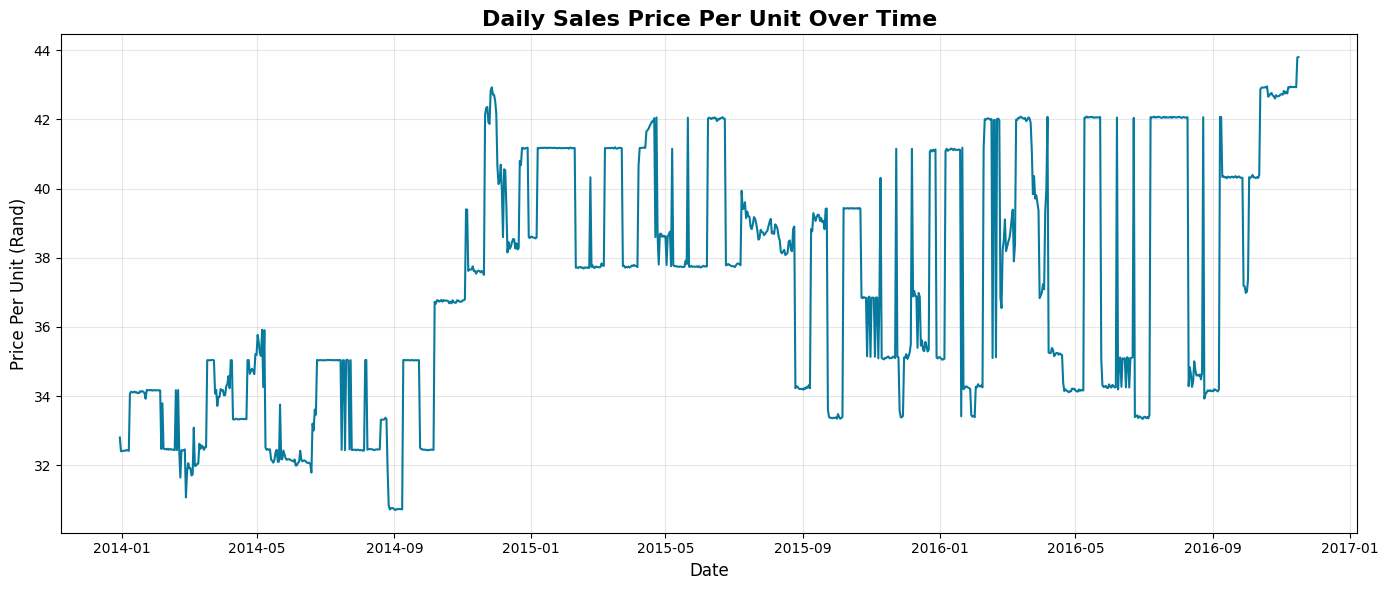

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Calculate Daily Sales Price Per Unit
Sales_df['Daily_Sales_Price_Per_Unit'] = Sales_df['Sales'] / Sales_df['Quantity Sold']

# Display first few rows
print("Sample Data with Price Per Unit:")
print(Sales_df[['Date', 'Sales', 'Quantity Sold', 'Daily_Sales_Price_Per_Unit']].head(10))

# Calculate summary statistics
print("\n=== Summary Statistics ===")
print(f"Average Price Per Unit: R{Sales_df['Daily_Sales_Price_Per_Unit'].mean():.2f}")
print(f"Median Price Per Unit: R{Sales_df['Daily_Sales_Price_Per_Unit'].median():.2f}")
print(f"Min Price Per Unit: R{Sales_df['Daily_Sales_Price_Per_Unit'].min():.2f}")
print(f"Max Price Per Unit: R{Sales_df['Daily_Sales_Price_Per_Unit'].max():.2f}")
print(f"Std Deviation: R{Sales_df['Daily_Sales_Price_Per_Unit'].std():.2f}")
print(f"Total Days: {len(Sales_df)}")

# Create visualization
plt.figure(figsize=(14, 6))
plt.plot(Sales_df['Date'], Sales_df['Daily_Sales_Price_Per_Unit'], linewidth=1.5, color='#077A9D')
plt.title('Daily Sales Price Per Unit Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Per Unit (Rand)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Loading data...

CORE PRICE METRICS
Volume-Weighted Average Price: R35.40
Simple Daily Average Price: R37.07
Median Price: R36.91
Price Range: R30.70 - R43.81
Standard Deviation: R3.45
Coefficient of Variation: 9.29%
Q1 (25th percentile): R34.18
Q3 (75th percentile): R40.33

Total Days Analyzed: 1,053
Total Units Sold: 5,279,872
Total Sales Revenue: R186,909,828.26

YEARLY PRICE TRENDS
      Days  Volume_Weighted_Price  Profit_Margin_Pct  Quantity Sold
Year                                                               
2013     2              32.574306          -2.476784          16095
2014   365              33.454872          -0.901284        2254230
2015   365              37.326106          -3.933584        1715089
2016   321              36.272305           2.642772        1294458

Year-over-Year Price Changes (%):
Year
2013          NaN
2014     2.703253
2015    11.571510
2016    -2.823226

PRICE SEGMENTATION ANALYSIS
                  Days  Avg_Quantity  Total_Quantity      Avg_

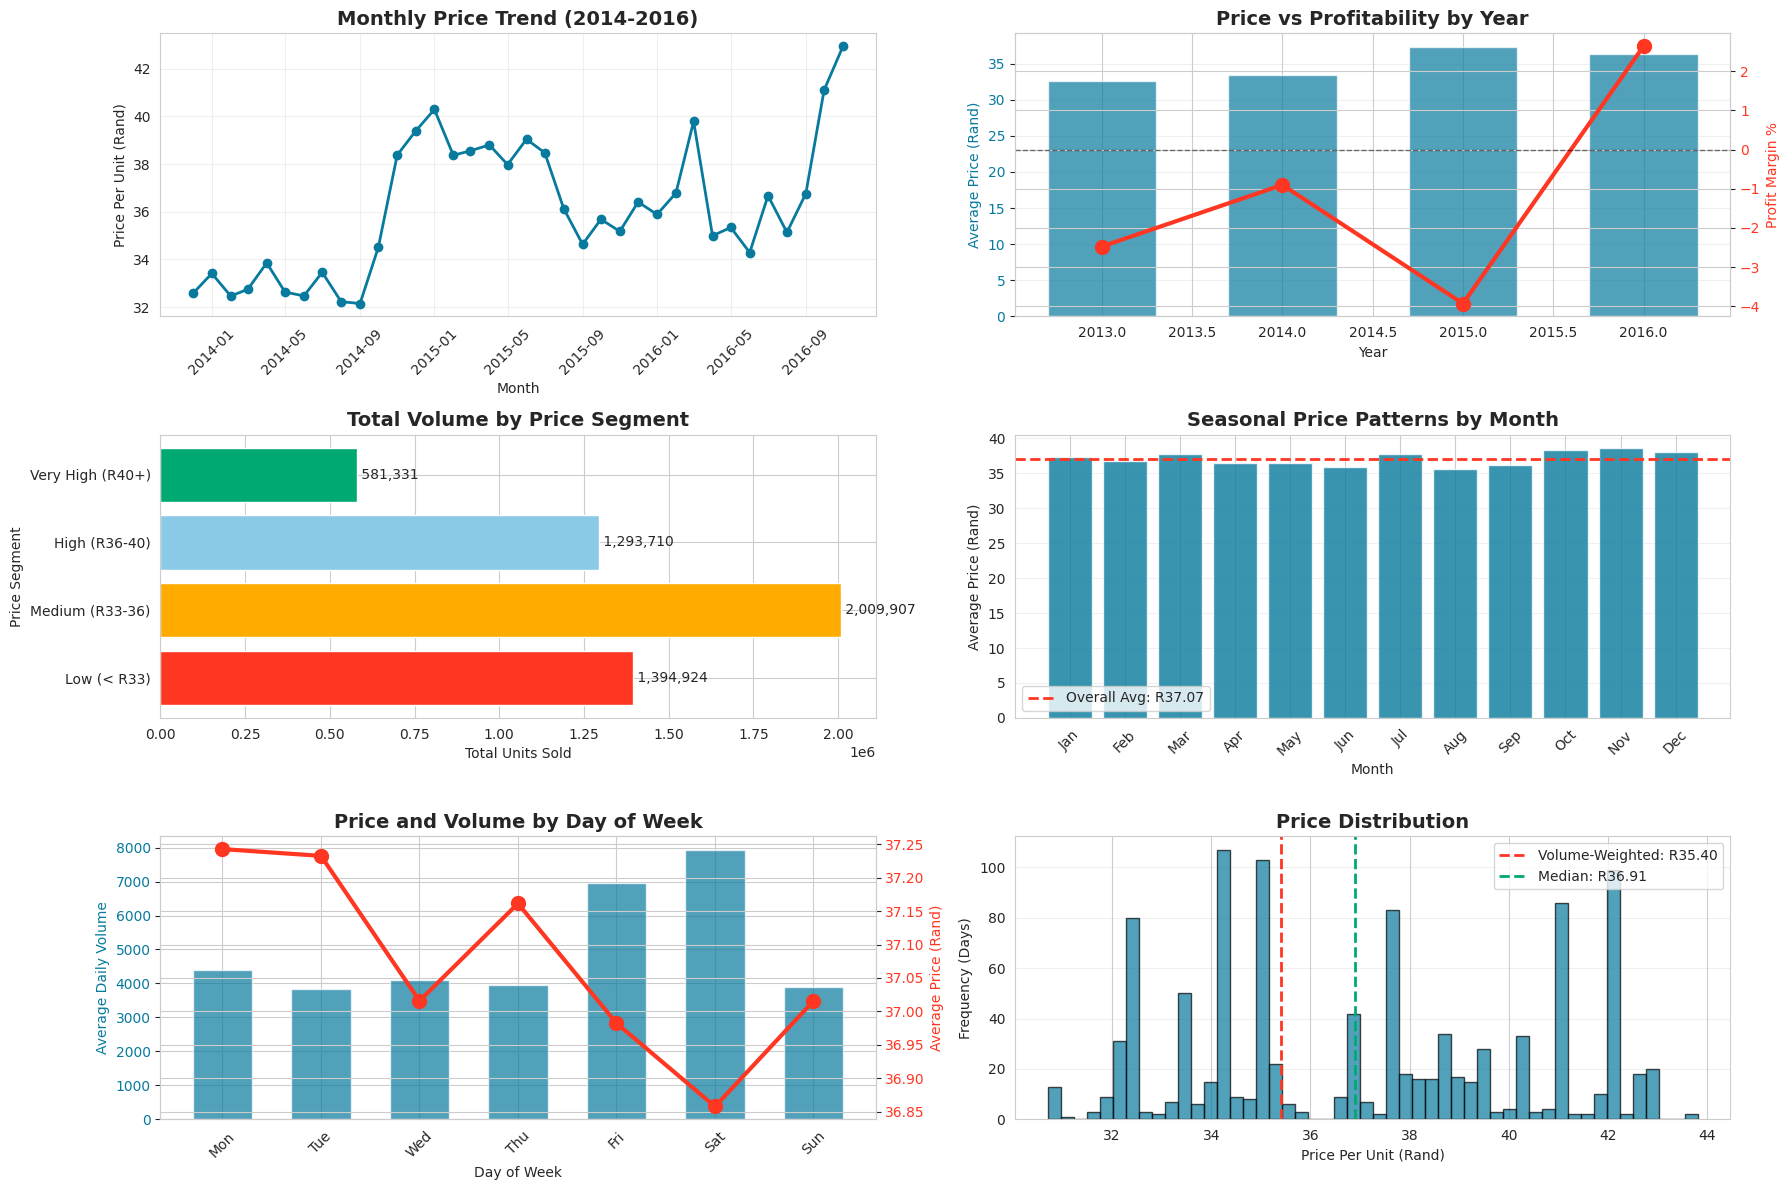

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

# ============================================
# LOAD AND PREPARE DATA
# ============================================
print("Loading data...")
df = pd.read_excel('/Workspace/Users/dagadarofhiwa@gmail.com/Sales case study/Sales_Case_Study.xlsx')
df['Date'] = pd.to_datetime(df['Date'])

# Calculate derived metrics
df['Unit_Price'] = df['Sales'] / df['Quantity Sold']
df['Unit_Cost'] = df['Cost Of Sales'] / df['Quantity Sold']
df['Unit_Profit'] = df['Unit_Price'] - df['Unit_Cost']
df['Profit_Margin_Pct'] = ((df['Sales'] - df['Cost Of Sales']) / df['Sales']) * 100
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Day_of_Week'] = df['Date'].dt.day_name()

# Sort by date for time series analysis
df = df.sort_values('Date')
df['Prev_Day_Price'] = df['Unit_Price'].shift(1)
df['Price_Change'] = df['Unit_Price'] - df['Prev_Day_Price']
df['Price_Change_Pct'] = (df['Price_Change'] / df['Prev_Day_Price']) * 100

# Price segmentation
def price_segment(price):
    if price < 33:
        return 'Low (< R33)'
    elif price < 36:
        return 'Medium (R33-36)'
    elif price < 40:
        return 'High (R36-40)'
    else:
        return 'Very High (R40+)'

df['Price_Segment'] = df['Unit_Price'].apply(price_segment)

# ============================================
# 1. CORE PRICE METRICS
# ============================================
print("\n" + "=" * 70)
print("CORE PRICE METRICS")
print("=" * 70)

volume_weighted_avg = df['Sales'].sum() / df['Quantity Sold'].sum()
simple_avg = df['Unit_Price'].mean()
median_price = df['Unit_Price'].median()
min_price = df['Unit_Price'].min()
max_price = df['Unit_Price'].max()
std_dev = df['Unit_Price'].std()
cv = (std_dev / simple_avg) * 100
q1 = df['Unit_Price'].quantile(0.25)
q3 = df['Unit_Price'].quantile(0.75)

print(f"Volume-Weighted Average Price: R{volume_weighted_avg:.2f}")
print(f"Simple Daily Average Price: R{simple_avg:.2f}")
print(f"Median Price: R{median_price:.2f}")
print(f"Price Range: R{min_price:.2f} - R{max_price:.2f}")
print(f"Standard Deviation: R{std_dev:.2f}")
print(f"Coefficient of Variation: {cv:.2f}%")
print(f"Q1 (25th percentile): R{q1:.2f}")
print(f"Q3 (75th percentile): R{q3:.2f}")
print(f"\nTotal Days Analyzed: {len(df):,}")
print(f"Total Units Sold: {df['Quantity Sold'].sum():,}")
print(f"Total Sales Revenue: R{df['Sales'].sum():,.2f}")

# ============================================
# 2. YEARLY TRENDS
# ============================================
print("\n" + "=" * 70)
print("YEARLY PRICE TRENDS")
print("=" * 70)

yearly_metrics = df.groupby('Year').agg({
    'Sales': 'sum',
    'Quantity Sold': 'sum',
    'Unit_Price': 'mean',
    'Unit_Cost': 'mean',
    'Unit_Profit': 'mean',
    'Profit_Margin_Pct': 'mean',
    'Date': 'count'
}).rename(columns={'Date': 'Days'})

yearly_metrics['Volume_Weighted_Price'] = yearly_metrics['Sales'] / yearly_metrics['Quantity Sold']
yearly_metrics['Price_YoY_Change_Pct'] = yearly_metrics['Volume_Weighted_Price'].pct_change() * 100

print(yearly_metrics[['Days', 'Volume_Weighted_Price', 'Profit_Margin_Pct', 'Quantity Sold']].to_string())
print("\nYear-over-Year Price Changes (%):")
print(yearly_metrics['Price_YoY_Change_Pct'].to_string())

# ============================================
# 3. PRICE SEGMENTATION ANALYSIS
# ============================================
print("\n" + "=" * 70)
print("PRICE SEGMENTATION ANALYSIS")
print("=" * 70)

segment_analysis = df.groupby('Price_Segment').agg({
    'Date': 'count',
    'Quantity Sold': ['mean', 'sum'],
    'Sales': ['mean', 'sum'],
    'Profit_Margin_Pct': 'mean'
})
segment_analysis.columns = ['Days', 'Avg_Quantity', 'Total_Quantity', 'Avg_Sales', 'Total_Sales', 'Avg_Profit_Margin_Pct']
segment_order = ['Low (< R33)', 'Medium (R33-36)', 'High (R36-40)', 'Very High (R40+)']
segment_analysis = segment_analysis.reindex(segment_order)

print(segment_analysis.to_string())

# ============================================
# 4. SEASONAL PATTERNS
# ============================================
print("\n" + "=" * 70)
print("SEASONAL PATTERNS BY MONTH")
print("=" * 70)

monthly_patterns = df.groupby(['Month', 'Month_Name']).agg({
    'Unit_Price': 'mean',
    'Quantity Sold': 'mean',
    'Sales': 'sum',
    'Date': 'count'
}).rename(columns={'Date': 'Days'}).sort_index()

print(monthly_patterns.to_string())

print("\n" + "=" * 70)
print("DAY OF WEEK PATTERNS")
print("=" * 70)

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_patterns = df.groupby('Day_of_Week').agg({
    'Unit_Price': 'mean',
    'Quantity Sold': 'mean',
    'Sales': 'sum',
    'Date': 'count'
}).rename(columns={'Date': 'Days'})
dow_patterns = dow_patterns.reindex(dow_order)

print(dow_patterns.to_string())

# ============================================
# 5. PRICE VOLATILITY ANALYSIS
# ============================================
print("\n" + "=" * 70)
print("TOP 10 LARGEST PRICE INCREASES")
print("=" * 70)

top_increases = df.nlargest(10, 'Price_Change_Pct')[
    ['Date', 'Unit_Price', 'Prev_Day_Price', 'Price_Change', 'Price_Change_Pct']
]
print(top_increases.to_string())

print("\n" + "=" * 70)
print("TOP 10 LARGEST PRICE DROPS")
print("=" * 70)

top_drops = df.nsmallest(10, 'Price_Change_Pct')[
    ['Date', 'Unit_Price', 'Prev_Day_Price', 'Price_Change', 'Price_Change_Pct']
]
print(top_drops.to_string())

# ============================================
# 6. VISUALIZATIONS
# ============================================
print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS...")
print("=" * 70)

fig = plt.figure(figsize=(18, 12))

# 1. Monthly Price Trend
ax1 = plt.subplot(3, 2, 1)
monthly_data = df.groupby(df['Date'].dt.to_period('M')).agg({'Sales': 'sum', 'Quantity Sold': 'sum'})
monthly_data['Price'] = monthly_data['Sales'] / monthly_data['Quantity Sold']
monthly_data.index = monthly_data.index.to_timestamp()
ax1.plot(monthly_data.index, monthly_data['Price'], linewidth=2, color='#077A9D', marker='o')
ax1.set_title('Monthly Price Trend (2014-2016)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Price Per Unit (Rand)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Yearly Price vs Profitability
ax2 = plt.subplot(3, 2, 2)
x = yearly_metrics.index
ax2_twin = ax2.twinx()
bars = ax2.bar(x, yearly_metrics['Volume_Weighted_Price'], color='#077A9D', alpha=0.7, width=0.6)
line = ax2_twin.plot(x, yearly_metrics['Profit_Margin_Pct'], color='#FF3621', marker='o', 
                      linewidth=3, markersize=10, label='Profit Margin %')
ax2.set_title('Price vs Profitability by Year', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Price (Rand)', color='#077A9D')
ax2_twin.set_ylabel('Profit Margin %', color='#FF3621')
ax2.tick_params(axis='y', labelcolor='#077A9D')
ax2_twin.tick_params(axis='y', labelcolor='#FF3621')
ax2_twin.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Price Segments - Volume
ax3 = plt.subplot(3, 2, 3)
segment_volumes = segment_analysis['Total_Quantity']
colors = ['#FF3621', '#FFAB00', '#8BCAE7', '#00A972']
bars = ax3.barh(segment_order, segment_volumes, color=colors)
ax3.set_title('Total Volume by Price Segment', fontsize=14, fontweight='bold')
ax3.set_xlabel('Total Units Sold')
ax3.set_ylabel('Price Segment')
for i, v in enumerate(segment_volumes):
    ax3.text(v, i, f' {v:,.0f}', va='center', fontsize=10)

# 4. Seasonal Patterns by Month
ax4 = plt.subplot(3, 2, 4)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = df.groupby('Month_Name')['Unit_Price'].mean().reindex(month_order)
bars = ax4.bar(range(12), monthly_avg, color='#077A9D', alpha=0.8)
ax4.axhline(y=simple_avg, color='#FF3621', linestyle='--', linewidth=2, label=f'Overall Avg: R{simple_avg:.2f}')
ax4.set_title('Seasonal Price Patterns by Month', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Average Price (Rand)')
ax4.set_xticks(range(12))
ax4.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Day of Week - Price and Volume
ax5 = plt.subplot(3, 2, 5)
ax5_twin = ax5.twinx()
dow_avg_price = df.groupby('Day_of_Week')['Unit_Price'].mean().reindex(dow_order)
dow_avg_qty = df.groupby('Day_of_Week')['Quantity Sold'].mean().reindex(dow_order)
x_pos = range(7)
bars = ax5.bar(x_pos, dow_avg_qty, color='#077A9D', alpha=0.7, width=0.6)
line = ax5_twin.plot(x_pos, dow_avg_price, color='#FF3621', marker='o', 
                     linewidth=3, markersize=10)
ax5.set_title('Price and Volume by Day of Week', fontsize=14, fontweight='bold')
ax5.set_xlabel('Day of Week')
ax5.set_ylabel('Average Daily Volume', color='#077A9D')
ax5_twin.set_ylabel('Average Price (Rand)', color='#FF3621')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([d[:3] for d in dow_order], rotation=45)
ax5.tick_params(axis='y', labelcolor='#077A9D')
ax5_twin.tick_params(axis='y', labelcolor='#FF3621')

# 6. Price Distribution Histogram
ax6 = plt.subplot(3, 2, 6)
ax6.hist(df['Unit_Price'], bins=50, color='#077A9D', alpha=0.7, edgecolor='black')
ax6.axvline(volume_weighted_avg, color='#FF3621', linestyle='--', linewidth=2, 
            label=f'Volume-Weighted: R{volume_weighted_avg:.2f}')
ax6.axvline(median_price, color='#00A972', linestyle='--', linewidth=2, 
            label=f'Median: R{median_price:.2f}')
ax6.set_title('Price Distribution', fontsize=14, fontweight='bold')
ax6.set_xlabel('Price Per Unit (Rand)')
ax6.set_ylabel('Frequency (Days)')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('unit_price_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved: unit_price_analysis.png")

# ============================================
# 7. EXPORT RESULTS TO EXCEL
# ============================================
print("\n" + "=" * 70)
print("EXPORTING RESULTS TO EXCEL...")
print("=" * 70)

summary_report = pd.DataFrame({
    'Metric': [
        'Volume-Weighted Avg Price', 'Simple Daily Avg Price', 'Median Price',
        'Min Price', 'Max Price', 'Price Range', 'Std Deviation',
        'Coefficient of Variation', 'Q1 (25th percentile)', 'Q3 (75th percentile)',
        'Total Days Analyzed', 'Total Units Sold', 'Total Sales Revenue'
    ],
    'Value': [
        f'R{volume_weighted_avg:.2f}', f'R{simple_avg:.2f}', f'R{median_price:.2f}',
        f'R{min_price:.2f}', f'R{max_price:.2f}', f'R{max_price - min_price:.2f}',
        f'R{std_dev:.2f}', f'{cv:.2f}%', f'R{q1:.2f}', f'R{q3:.2f}',
        f'{len(df):,}', f'{df["Quantity Sold"].sum():,}', f'R{df["Sales"].sum():,.2f}'
    ]
})

with pd.ExcelWriter('unit_price_analysis_results.xlsx', engine='openpyxl') as writer:
    summary_report.to_excel(writer, sheet_name='Summary', index=False)
    yearly_metrics.to_excel(writer, sheet_name='Yearly Trends')
    segment_analysis.to_excel(writer, sheet_name='Price Segments')
    monthly_patterns.to_excel(writer, sheet_name='Monthly Patterns')
    dow_patterns.to_excel(writer, sheet_name='Day of Week')
    top_increases.to_excel(writer, sheet_name='Top Price Increases', index=False)
    top_drops.to_excel(writer, sheet_name='Top Price Drops', index=False)
    df[['Date', 'Unit_Price', 'Unit_Cost', 'Unit_Profit', 'Profit_Margin_Pct', 
        'Quantity Sold', 'Sales', 'Price_Segment']].to_excel(writer, sheet_name='Daily Data', index=False)

print("Excel report saved: unit_price_analysis_results.xlsx")

# ============================================
# 8. SUMMARY INSIGHTS
# ============================================
print("\n" + "=" * 70)
print("KEY INSIGHTS SUMMARY")
print("=" * 70)

print(f"\n1. PRICING:")
print(f"   - Average unit price is R{volume_weighted_avg:.2f}")
print(f"   - Prices range from R{min_price:.2f} to R{max_price:.2f} ({((max_price-min_price)/min_price*100):.1f}% spread)")
print(f"   - Price volatility (CV) is {cv:.1f}% - moderate stability")

print(f"\n2. PROFITABILITY:")
profitable_years = yearly_metrics[yearly_metrics['Profit_Margin_Pct'] > 0]
if len(profitable_years) > 0:
    print(f"   - Achieved profitability in: {', '.join(map(str, profitable_years.index))}")
    print(f"   - Best margin: {yearly_metrics['Profit_Margin_Pct'].max():.2f}% in {yearly_metrics['Profit_Margin_Pct'].idxmax()}")
else:
    print(f"   - No profitable years in the dataset")

print(f"\n3. PRICE SEGMENTS:")
profitable_segments = segment_analysis[segment_analysis['Avg_Profit_Margin_Pct'] > 0]
if len(profitable_segments) > 0:
    print(f"   - Profitable segments: {', '.join(profitable_segments.index)}")
    best_segment = segment_analysis['Avg_Profit_Margin_Pct'].idxmax()
    print(f"   - Best margin: {segment_analysis.loc[best_segment, 'Avg_Profit_Margin_Pct']:.2f}% in {best_segment}")
else:
    print(f"   - No profitable price segments")

print(f"\n4. SEASONALITY:")
highest_month = monthly_patterns['Unit_Price'].idxmax()[1]
lowest_month = monthly_patterns['Unit_Price'].idxmin()[1]
print(f"   - Highest prices: {highest_month} (R{monthly_patterns['Unit_Price'].max():.2f})")
print(f"   - Lowest prices: {lowest_month} (R{monthly_patterns['Unit_Price'].min():.2f})")
print(f"   - Seasonal variation: {((monthly_patterns['Unit_Price'].max() - monthly_patterns['Unit_Price'].min()) / monthly_patterns['Unit_Price'].min() * 100):.1f}%")

print(f"\n5. WEEKLY PATTERNS:")
highest_volume_day = dow_patterns['Quantity Sold'].idxmax()
print(f"   - Highest volume day: {highest_volume_day} ({dow_patterns.loc[highest_volume_day, 'Quantity Sold']:.0f} units)")
weekend_avg = dow_patterns.loc[['Saturday', 'Sunday'], 'Quantity Sold'].mean()
weekday_avg = dow_patterns.loc[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'], 'Quantity Sold'].mean()
weekend_vs_weekday_pct = ((weekend_avg / weekday_avg - 1) * 100)
print(f"   - Weekend vs Weekday volume: {weekend_vs_weekday_pct:.1f}% higher on weekends")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)
print("\nFiles generated:")
print("  ✓ unit_price_analysis.png (visualizations)")
print("  ✓ unit_price_analysis_results.xlsx (detailed data)")
print("\nAll metrics, trends, and insights have been calculated and exported.")

In [0]:
display(Sales_df)

Date,Sales,Cost Of Sales,Quantity Sold,Day_name,Month_name,Year,Day_Classification,Daily_Sales_Price_Per_Unit,Daily_Gross_Profit_Pct,Daily_Gross_Profit_Pct_Per_Unit
2013-12-30T00:00:00.000Z,223937.96786972653,230079.62101244804,6827,Monday,December,2013,Weekday,32.801811611209395,-2.74256893600747,-2.7425689360074688
2013-12-31T00:00:00.000Z,300345.48456398566,306986.1204842832,9268,Tuesday,December,2013,Weekday,32.40672038886336,-2.2109990865811757,-2.2109990865811895
2014-01-01T00:00:00.000Z,86782.4677274178,87986.31821444989,2678,Wednesday,January,2014,Weekday,32.40570116781844,-1.387204718369341,-1.387204718369352
2014-01-02T00:00:00.000Z,200173.11675267716,202881.17770623261,6175,Thursday,January,2014,Weekday,32.41669906925946,-1.3528594635918991,-1.352859463591905
2014-01-03T00:00:00.000Z,326906.07417633064,333806.2918733548,10084,Friday,January,2014,Weekday,32.41829375013196,-2.110764602465675,-2.1107646024656765
2014-01-04T00:00:00.000Z,307043.9354221619,313652.34827236354,9470,Saturday,January,2014,Weekend,32.42280205091467,-2.15226945978125,-2.15226945978125
2014-01-05T00:00:00.000Z,179188.88448780973,183083.28498402698,5524,Sunday,January,2014,Weekend,32.43824845905317,-2.173349372283293,-2.1733493722832993
2014-01-06T00:00:00.000Z,306351.9508589919,313446.068148843,9448,Monday,January,2014,Weekday,32.42505830429635,-2.315675571825041,-2.31567557182504
2014-01-07T00:00:00.000Z,224020.40996847834,229533.97372837967,6911,Tuesday,January,2014,Weekday,32.41504991585564,-2.4611881393651296,-2.4611881393651465
2014-01-08T00:00:00.000Z,101836.4022362371,99381.96751722493,2990,Wednesday,January,2014,Weekday,34.05899740342378,2.4101742256353984,2.4101742256354055


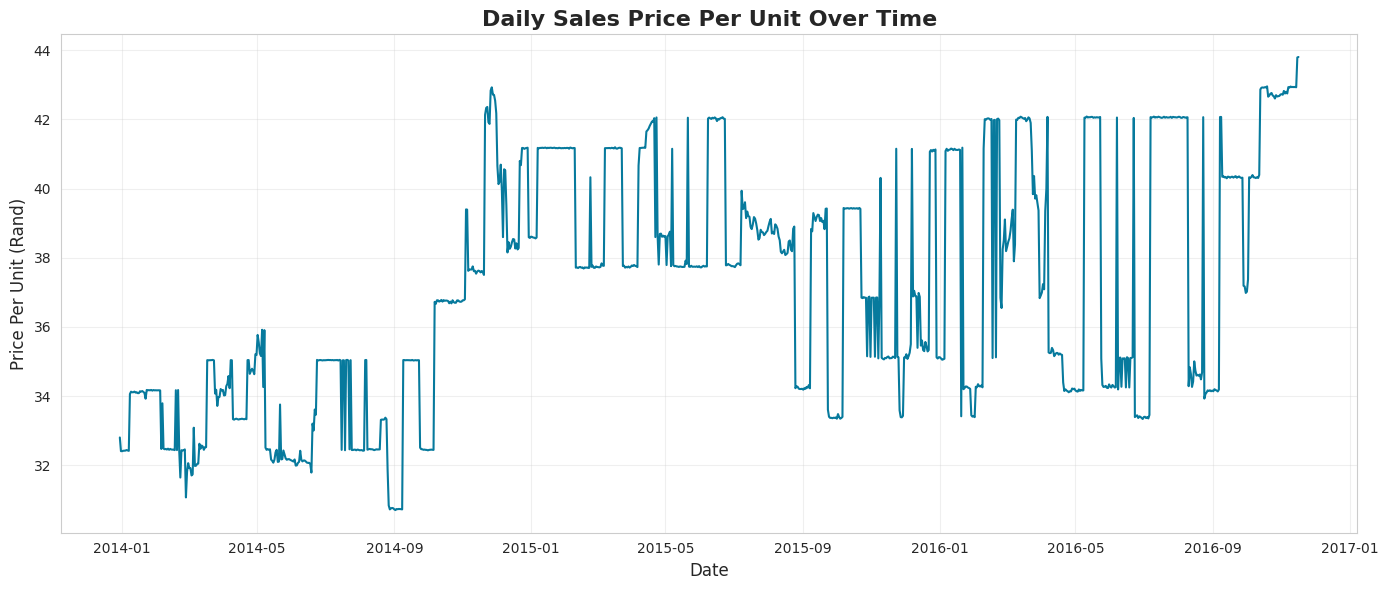

In [0]:
import matplotlib.pyplot as plt

# Plot Daily Sales Price Per Unit over time
plt.figure(figsize=(14, 6))
plt.plot(Sales_df['Date'], Sales_df['Daily_Sales_Price_Per_Unit'], linewidth=1.5, color='#077A9D')
plt.title('Daily Sales Price Per Unit Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Per Unit (Rand)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== Dashboard Summary ===
Average Price Per Unit: R37.07
Median Price Per Unit: R36.91
Min Price Per Unit: R30.70
Max Price Per Unit: R43.81
Std Deviation: 3.45
Total Sales: R186909828.26
Total Units Sold: 5279872.00
Total Days: 1053.00


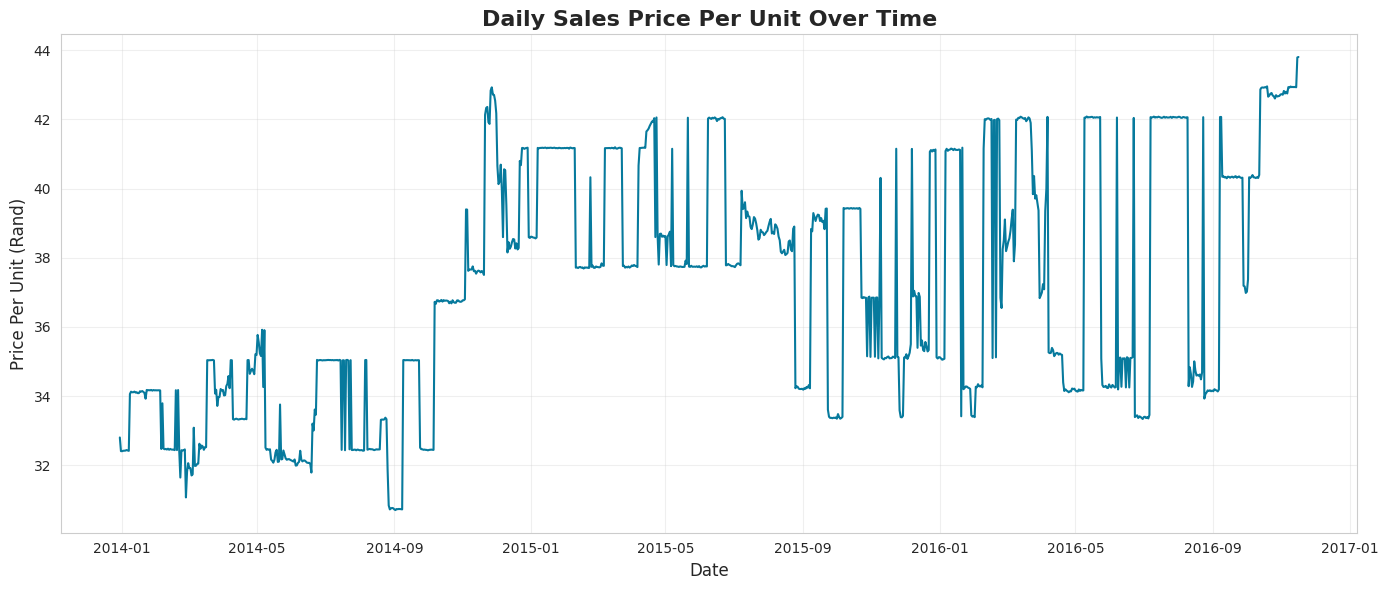

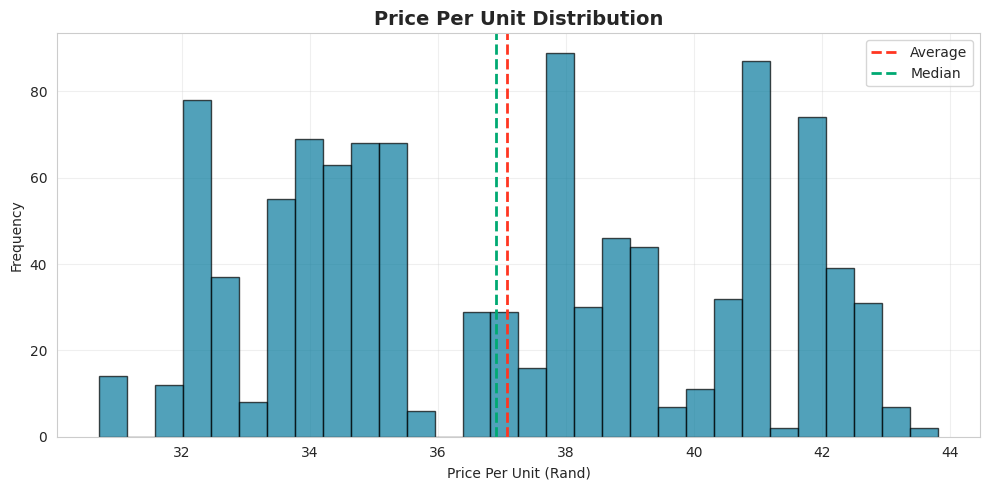

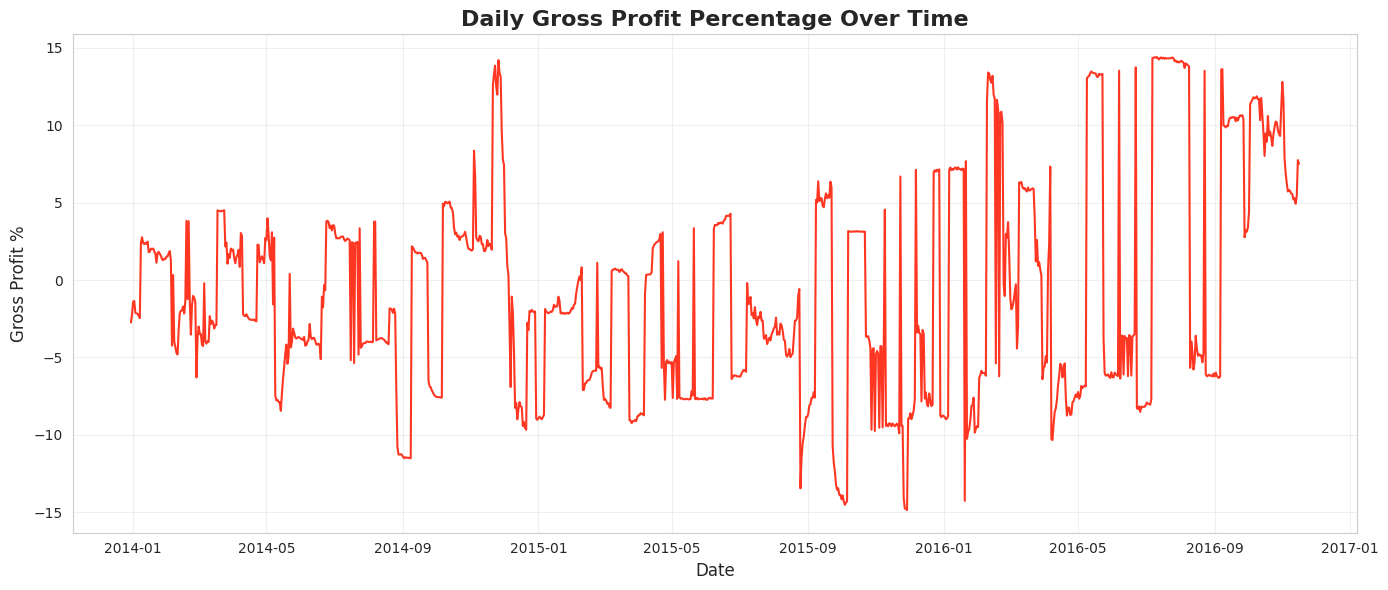

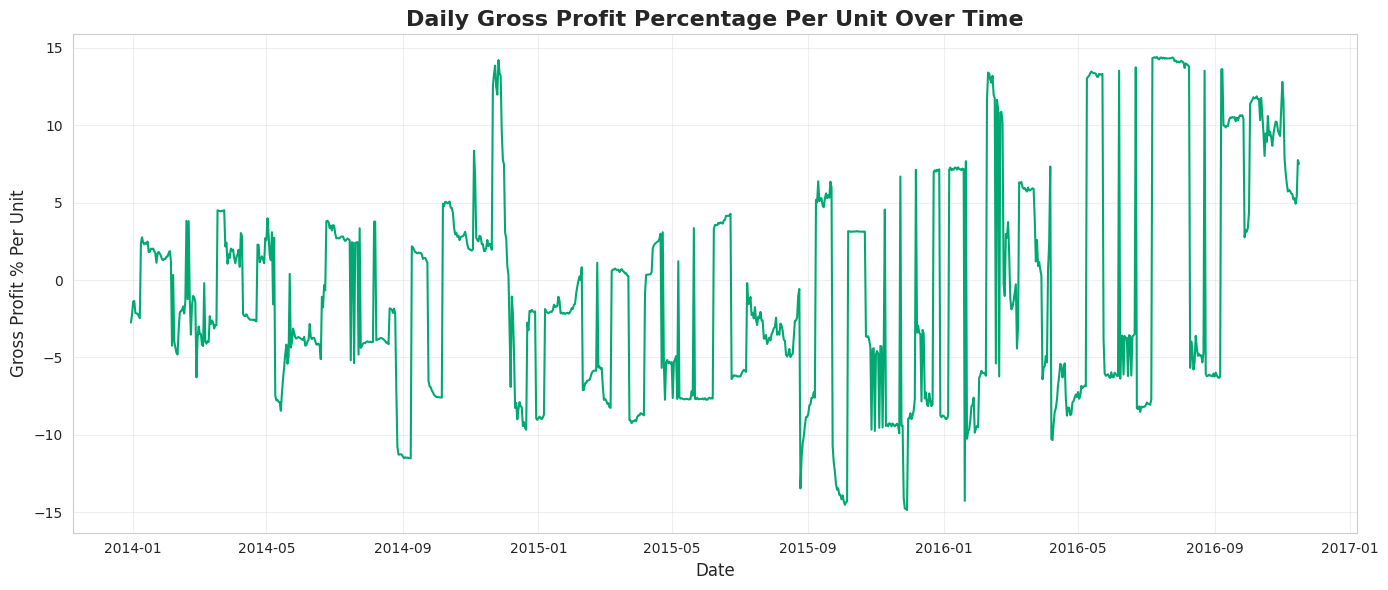

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dashboard: Summary statistics
summary_stats = {
    'Average Price Per Unit': Sales_df['Daily_Sales_Price_Per_Unit'].mean(),
    'Median Price Per Unit': Sales_df['Daily_Sales_Price_Per_Unit'].median(),
    'Min Price Per Unit': Sales_df['Daily_Sales_Price_Per_Unit'].min(),
    'Max Price Per Unit': Sales_df['Daily_Sales_Price_Per_Unit'].max(),
    'Std Deviation': Sales_df['Daily_Sales_Price_Per_Unit'].std(),
    'Total Sales': Sales_df['Sales'].sum(),
    'Total Units Sold': Sales_df['Quantity Sold'].sum(),
    'Total Days': len(Sales_df)
}

print("\n=== Dashboard Summary ===")
for k, v in summary_stats.items():
    if 'Price' in k or 'Sales' in k:
        print(f"{k}: R{v:.2f}")
    else:
        print(f"{k}: {v:.2f}")

# Chart 1: Daily Sales Price Per Unit Over Time
plt.figure(figsize=(14, 6))
plt.plot(Sales_df['Date'], Sales_df['Daily_Sales_Price_Per_Unit'], color='#077A9D', linewidth=1.5)
plt.title('Daily Sales Price Per Unit Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Per Unit (Rand)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 2: Price Distribution Histogram
plt.figure(figsize=(10, 5))
plt.hist(Sales_df['Daily_Sales_Price_Per_Unit'], bins=30, color='#077A9D', alpha=0.7, edgecolor='black')
plt.axvline(summary_stats['Average Price Per Unit'], color='#FF3621', linestyle='--', linewidth=2, label='Average')
plt.axvline(summary_stats['Median Price Per Unit'], color='#00A972', linestyle='--', linewidth=2, label='Median')
plt.title('Price Per Unit Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price Per Unit (Rand)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 3: Daily Gross Profit Percentage Over Time
plt.figure(figsize=(14, 6))
plt.plot(Sales_df['Date'], Sales_df['Daily_Gross_Profit_Pct'], color='#FF3621', linewidth=1.5)
plt.title('Daily Gross Profit Percentage Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Gross Profit %', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 4: Daily Gross Profit Percentage Per Unit Over Time
plt.figure(figsize=(14, 6))
plt.plot(Sales_df['Date'], Sales_df['Daily_Gross_Profit_Pct_Per_Unit'], color='#00A972', linewidth=1.5)
plt.title('Daily Gross Profit Percentage Per Unit Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Gross Profit % Per Unit', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()